# mean_balance over epochs

This notebook compares the original `sep_etd_f1` score with the heuristic `mean_balance` on the saved `SEP` and `ETD` values from this optimization process.

- `mean_balance = ((SEP + ETD) / 2) * (1 - |SEP - ETD|)`

Train and validation curves are shown together in a single chart, following the same style used in `plot_optimization_process.ipynb`.


In [ ]:
import json
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display


def find_local_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "run_prompt_optimizer.py").exists() and (candidate / "out").exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate the explainability-with-LLMs project root from the current working directory."
    )


PROJECT_ROOT = find_local_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 160)

PROJECT_ROOT


PosixPath('/mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_WebMedia/origin/06_prompt-optimization/prompt-optim-expl-rec/explainability-with-LLMs')

In [ ]:
PROCESS_DIR_REL = "out/prompt_optimization/Llama3.1-I/item_knn/sep_etd_f1/repr_llm2vec/early_false/mmr_lambda_0_0/mmr_pool_10/Llama3.1-I/prompt_opt/sep_etd_f1"
METADATA_PATH = PROJECT_ROOT / PROCESS_DIR_REL / "optimization_process_metadata.json"

with METADATA_PATH.open("r", encoding="utf-8") as file_obj:
    metadata = json.load(file_obj)

rows = []
for epoch_payload in metadata["epochs_history"]:
    train_scores = epoch_payload.get("train_metric_scores", {})
    val_scores = epoch_payload.get("val_metric_scores", {})
    rows.append(
        {
            "epoch_zero_based": int(epoch_payload["epoch"]),
            "epoch": int(epoch_payload["epoch"]) + 1,
            "train_sep": float(train_scores.get("sep", 0.0)),
            "train_etd": float(train_scores.get("etd", 0.0)),
            "train_sep_etd_f1": float(train_scores.get("sep_etd_f1", 0.0)),
            "val_sep": float(val_scores.get("sep", 0.0)),
            "val_etd": float(val_scores.get("etd", 0.0)),
            "val_sep_etd_f1": float(val_scores.get("sep_etd_f1", 0.0)),
        }
    )

history = pd.DataFrame(rows).sort_values("epoch_zero_based").reset_index(drop=True)

display(Markdown(f"## Process loaded from `{PROCESS_DIR_REL}`"))
history


## Process loaded from `out/prompt_optimization/Llama3.1-I/item_knn/sep_etd_f1/repr_llm2vec/early_false/mmr_lambda_0_0/mmr_pool_10/Llama3.1-I/prompt_opt/sep_etd_f1`

,epoch_zero_based,epoch,train_sep,train_etd,train_sep_etd_f1,val_sep,val_etd,val_sep_etd_f1
0,0,1,0.645556,0.761282,0.698659,0.643379,0.755102,0.694778
1,1,2,0.707057,0.684615,0.695655,0.702149,0.679592,0.690686
2,2,3,0.632052,0.790256,0.702356,0.627641,0.813265,0.708497
3,3,4,0.619413,0.802051,0.698999,0.636369,0.787755,0.704015
4,4,5,0.615236,0.798718,0.695072,0.609938,0.809184,0.695574
5,5,6,0.691560,0.702405,0.696941,0.691057,0.708163,0.699506
6,6,7,0.640872,0.775641,0.701845,0.642100,0.759184,0.695751
7,7,8,0.703808,0.683960,0.693742,0.717838,0.671429,0.693858
8,8,9,0.644454,0.771282,0.702187,0.627346,0.797959,0.702441
9,9,10,0.591909,0.827179,0.690041,0.595446,0.814286,0.687880


In [ ]:
def mean_balance(sep_value: float, etd_value: float) -> float:
    sep_value = float(sep_value)
    etd_value = float(etd_value)
    mean_value = (sep_value + etd_value) / 2.0
    gap = abs(sep_value - etd_value)
    return float(mean_value * (1.0 - gap))


for split in ["train", "val"]:
    history[f"{split}_mean_balance"] = history.apply(
        lambda row: mean_balance(row[f"{split}_sep"], row[f"{split}_etd"]),
        axis=1,
    )

display(Markdown("## Values by epoch"))
history[[
    "epoch",
    "train_sep",
    "train_etd",
    "train_sep_etd_f1",
    "train_mean_balance",
    "val_sep",
    "val_etd",
    "val_sep_etd_f1",
    "val_mean_balance",
]]


## Values by epoch

,epoch,train_sep,train_etd,train_sep_etd_f1,train_mean_balance,val_sep,val_etd,val_sep_etd_f1,val_mean_balance
0,1,0.645556,0.761282,0.698659,0.622015,0.643379,0.755102,0.694778,0.621119
1,2,0.707057,0.684615,0.695655,0.680220,0.702149,0.679592,0.690686,0.675286
2,3,0.632052,0.790256,0.702356,0.598647,0.627641,0.813265,0.708497,0.586719
3,4,0.619413,0.802051,0.698999,0.580926,0.636369,0.787755,0.704015,0.604265
4,5,0.615236,0.798718,0.695072,0.577260,0.609938,0.809184,0.695574,0.568184
5,6,0.691560,0.702405,0.696941,0.689424,0.691057,0.708163,0.699506,0.687642
6,7,0.640872,0.775641,0.701845,0.612805,0.642100,0.759184,0.695751,0.618608
7,8,0.703808,0.683960,0.693742,0.680112,0.717838,0.671429,0.693858,0.662396
8,9,0.644454,0.771282,0.702187,0.618090,0.627346,0.797959,0.702441,0.591064
9,10,0.591909,0.827179,0.690041,0.542609,0.595446,0.814286,0.687880,0.550614


In [ ]:
summary_rows = []
for split in ["train", "val"]:
    for metric_name in ["sep_etd_f1", "mean_balance"]:
        column = f"{split}_{metric_name}"
        best_idx = history[column].idxmax()
        summary_rows.append(
            {
                "split": split,
                "metric": metric_name,
                "best_epoch": int(history.loc[best_idx, "epoch"]),
                "best_value": float(history.loc[best_idx, column]),
                "sep_at_best": float(history.loc[best_idx, f"{split}_sep"]),
                "etd_at_best": float(history.loc[best_idx, f"{split}_etd"]),
            }
        )

summary_df = pd.DataFrame(summary_rows)
display(Markdown("## Best epoch for `sep_etd_f1` vs `mean_balance`"))
summary_df


## Best epoch for `sep_etd_f1` vs `mean_balance`

,split,metric,best_epoch,best_value,sep_at_best,etd_at_best
0,train,sep_etd_f1,3,0.702356,0.632052,0.790256
1,train,mean_balance,6,0.689424,0.691560,0.702405
2,val,sep_etd_f1,3,0.708497,0.627641,0.813265
3,val,mean_balance,6,0.687642,0.691057,0.708163


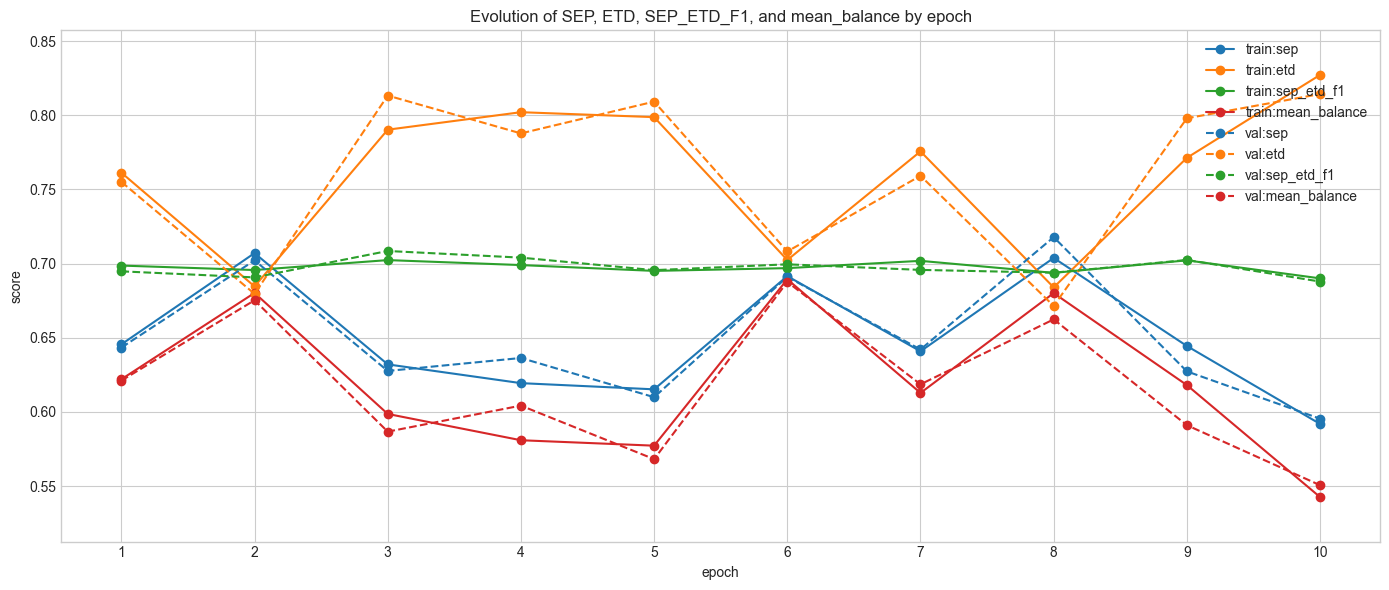

In [ ]:
epoch_values = history["epoch"].tolist()
score_columns = [
    "train_sep",
    "train_etd",
    "train_sep_etd_f1",
    "train_mean_balance",
    "val_sep",
    "val_etd",
    "val_sep_etd_f1",
    "val_mean_balance",
]
y_min = max(0.0, float(history[score_columns].min().min()) - 0.03)
y_max = min(1.0, float(history[score_columns].max().max()) + 0.03)

plt.figure(figsize=(14, 6))
plt.plot(epoch_values, history["train_sep"], marker="o", linestyle="-", color="#1f77b4", label="train:sep")
plt.plot(epoch_values, history["train_etd"], marker="o", linestyle="-", color="#ff7f0e", label="train:etd")
plt.plot(epoch_values, history["train_sep_etd_f1"], marker="o", linestyle="-", color="#2ca02c", label="train:sep_etd_f1")
plt.plot(epoch_values, history["train_mean_balance"], marker="o", linestyle="-", color="#d62728", label="train:mean_balance")
plt.plot(epoch_values, history["val_sep"], marker="o", linestyle="--", color="#1f77b4", label="val:sep")
plt.plot(epoch_values, history["val_etd"], marker="o", linestyle="--", color="#ff7f0e", label="val:etd")
plt.plot(epoch_values, history["val_sep_etd_f1"], marker="o", linestyle="--", color="#2ca02c", label="val:sep_etd_f1")
plt.plot(epoch_values, history["val_mean_balance"], marker="o", linestyle="--", color="#d62728", label="val:mean_balance")
plt.title("Evolution of SEP, ETD, SEP_ETD_F1, and mean_balance by epoch")
plt.xlabel("epoch")
plt.ylabel("score")
plt.xticks(epoch_values)
plt.ylim(y_min, y_max)
plt.legend(loc="best")
plt.tight_layout()
plt.show()
